# Checkpoint 3 — Diarization: Data Preparation and Analysis

**Datasets:**
- `VoxConverse test`
- `AMI IHM test`


## 0. Setup

In [1]:
!pip install datasets==3.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [33]:
import os
import random
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import soundfile as sf
import librosa
from datasets import load_dataset
from tqdm.auto import tqdm
import requests
from collections import defaultdict

In [3]:
SEED = 31122002
random.seed(SEED)
np.random.seed(SEED)

PROCESSED_DIR = Path("data/processed")
MANIFEST_DIR = Path("data/manifests")
RTTM_DIR = Path("data/rttm")
EDA_DIR = Path("eda/diarization")
for d in [PROCESSED_DIR, MANIFEST_DIR, RTTM_DIR, EDA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16_000
TARGET_SUBTYPE = "PCM_16"
PEAK_TARGET = 0.9

## 1. RTTM Format

RTTM (Rich Transcription Time Mark) is the standard annotation format for diarization.  
Every line describes one speech segment:

```
SPEAKER <file_id> 1 <start_sec> <duration_sec> <NA> <NA> <speaker_id> <NA> <NA>
```

In [5]:
def parse_rttm_string(rttm_text, file_id = None):
    """
    Parse RTTM text (string) into a DataFrame.
    Only SPEAKER lines are kept; other line types are skipped.
    """
    rows = []
    for line in rttm_text.strip().splitlines():
        line = line.strip()
        if not line.startswith("SPEAKER"):
            continue
        parts = line.split()
        if len(parts) < 8:
            continue
        rows.append({
            "file_id": file_id or parts[1],
            "start": float(parts[3]),
            "duration": float(parts[4]),
            "speaker_id": parts[7],
        })
    if not rows:
        return pd.DataFrame(columns=["file_id", "start", "duration", "end", "speaker_id"])
    df = pd.DataFrame(rows)
    df["end"] = df["start"] + df["duration"]
    return df.sort_values("start").reset_index(drop=True)


def parse_rttm_file(path: Path, file_id: str = None) -> pd.DataFrame:
    return parse_rttm_string(Path(path).read_text(), file_id=file_id)


def write_rttm(df: pd.DataFrame, path: Path) -> None:
    """Write DataFrame back to RTTM format"""
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        for _, r in df.iterrows():
            f.write(
                f"SPEAKER {r['file_id']} 1 {r['start']:.3f} "
                f"{r['duration']:.3f} <NA> <NA> {r['speaker_id']} <NA> <NA>\n"
            )

In [6]:
def overlap_duration(rttm_df):
    """
    Total duration where 2+ speakers are active simultaneously.
    """
    if rttm_df.empty:
        return 0.0
    events = []
    for _, r in rttm_df.iterrows():
        events.append((r["start"], +1))
        events.append((r["end"],   -1))
    events.sort(key=lambda x: (x[0], x[1]))
    total, active, prev = 0.0, 0, 0.0
    for t, delta in events:
        if active >= 2:
            total += t - prev
        prev = t
        active += delta
    return total


def recording_stats(rttm_df: pd.DataFrame, audio_dur: float) -> dict:
    """Per-recording summary statistics derived from RTTM."""
    if rttm_df.empty:
        return {}
    ov = overlap_duration(rttm_df)
    sp = rttm_df["duration"].sum()
    return {
        "n_speakers": rttm_df["speaker_id"].nunique(),
        "n_segments": len(rttm_df),
        "speech_dur": round(sp, 3),
        "overlap_dur": round(ov, 3),
        "overlap_ratio": round(ov / audio_dur, 4) if audio_dur > 0 else 0.0,
        "silence_ratio": round(max(0, audio_dur - sp) / audio_dur, 4),
        "mean_segment_sec": round(rttm_df["duration"].mean(), 3),
    }


# Verify: expected overlap ~0.90 s
ov = overlap_duration(df_test)
st = recording_stats(df_test, audio_dur=10.0)
print(f"Overlap duration : {ov:.2f} s  (expected ~0.90)")
print(f"Recording stats  : {st}")

NameError: name 'df_test' is not defined

## 2. Preprocessing

In [8]:
def preprocess(array: np.ndarray, src_sr: int) -> np.ndarray:
    y = array.astype(np.float32)
    if src_sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=src_sr, target_sr=TARGET_SR)
    if y.ndim > 1:
        y = librosa.to_mono(y)
    peak = np.max(np.abs(y))
    if peak > 0:
        y = y / peak * PEAK_TARGET
    return y

def save_audio(array: np.ndarray, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(str(path), array, TARGET_SR, subtype=TARGET_SUBTYPE)

## 3. VoxConverse.

In [9]:
#https://huggingface.co/datasets/diarizers-community/voxconverse
vc_raw = load_dataset(
    "diarizers-community/voxconverse",
    split="test",
    trust_remote_code=True,
)
print(len(vc_raw))
print(vc_raw.features)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/dev-00000-of-00005.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/dev-00001-of-00005.parquet:   0%|          | 0.00/449M [00:00<?, ?B/s]

data/dev-00002-of-00005.parquet:   0%|          | 0.00/492M [00:00<?, ?B/s]

...

data/test-00009-of-00011.parquet:   0%|          | 0.00/365M [00:00<?, ?B/s]

data/test-00010-of-00011.parquet:   0%|          | 0.00/395M [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/216 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/232 [00:00<?, ? examples/s]

232
{'audio': Audio(sampling_rate=None, mono=True, decode=True, id=None), 'timestamps_start': Sequence(feature=Value(dtype='float64', id=None), length=-1, id=None), 'timestamps_end': Sequence(feature=Value(dtype='float64', id=None), length=-1, id=None), 'speakers': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)}


In [12]:
def parse_voxconverse_sample(sample, file_id):
    starts = sample["timestamps_start"]
    ends = sample["timestamps_end"]
    speakers = sample["speakers"]

    df = pd.DataFrame({
        "file_id": file_id,
        "start": starts,
        "end": ends,
        "speaker_id": speakers,
    })
    df["duration"] = df["end"] - df["start"]
    return df.sort_values("start").reset_index(drop=True)

In [13]:
s = vc_raw[0]
file_id = s.get("audio_id", s.get("id", "vc_00000"))
df_test = parse_voxconverse_sample(s, file_id)
print(df_test.head())

    file_id  start    end speaker_id  duration
0  vc_00000   0.00   4.13      spk00      4.13
1  vc_00000   4.20   5.51      spk01      1.31
2  vc_00000   7.67  51.96      spk02     44.29
3  vc_00000  52.78  67.48      spk02     14.70
4  vc_00000  68.40  84.99      spk02     16.59


In [18]:
def process_voxconverse(dataset):
    rows = []
    for i, sample in enumerate(tqdm(dataset, desc="VoxConverse")):
        file_id = sample.get("audio_id", sample.get("id", f"vc_{i:05d}"))

        audio = sample["audio"]
        proc = preprocess(np.array(audio["array"], dtype=np.float32), audio["sampling_rate"])
        dur = len(proc) / TARGET_SR
        out_wav = PROCESSED_DIR / "voxconverse_test" / f"{file_id}.wav"
        out_rttm = RTTM_DIR / "voxconverse_test" / f"{file_id}.rttm"
        save_audio(proc, out_wav)
        rttm_df = parse_voxconverse_sample(sample, file_id)

        write_rttm(rttm_df, out_rttm)

        stats = recording_stats(rttm_df, dur)
        rows.append({
            "id": file_id,
            "audio_path": str(out_wav),
            "rttm_path": str(out_rttm),
            "duration_sec": round(dur, 3),
            "n_speakers": stats.get("n_speakers"),
            "n_segments": stats.get("n_segments"),
            "overlap_ratio": stats.get("overlap_ratio"),
            "silence_ratio": stats.get("silence_ratio"),
            "mean_segment_sec": stats.get("mean_segment_sec"),
        })
    return pd.DataFrame(rows)

In [19]:
m_vc = process_voxconverse(vc_raw)
m_vc.to_csv(MANIFEST_DIR / "diar_voxconverse_test.csv", index=False)
print(m_vc[["duration_sec", "n_speakers", "overlap_ratio"]].describe().round(3))

VoxConverse:   0%|          | 0/232 [00:00<?, ?it/s]

       duration_sec  n_speakers  overlap_ratio
count       232.000     232.000        232.000
mean        675.561       6.478          0.033
std         439.478       3.944          0.051
min          26.048       1.000          0.000
25%         222.960       3.000          0.001
50%         650.848       6.000          0.013
75%        1200.064       9.000          0.043
max        1200.064      21.000          0.385


---
## 4. AMI Meeting Corpus (IHM test)

AMI [18] requires more setup than VoxConverse because:
- The HuggingFace version stores data **per segment** (for ASR use), not per meeting
- Diarization needs **full meeting recordings** + **separate RTTM files**

**Setup steps (do once before running this cell):**

**Step 1 — Download RTTM files:**
```bash
git clone https://github.com/BUTspeechFIT/AMI-diarization-setup
# RTTM files are at: AMI-diarization-setup/only_words/rttms/test/
```
Set `AMI_RTTM_DIR` below to that folder.

**Step 2 — Download full meeting audio:**  
The full AMI corpus (IHM = Individual Headset Mic) can be downloaded with:
```bash
# Option A: official AMI downloader
# https://groups.inf.ed.ac.uk/ami/download/

# Option B: HuggingFace (full recordings)
# https://huggingface.co/datasets/edinburghcstr/ami  -- check if full-meeting WAVs are available
```
Audio file naming convention: `<meeting_id>.Mix-Headset.wav`  
Set `AMI_AUDIO_DIR` below to the folder containing these WAV files.

IHM is selected because we have pyannote benchmark on IHM


In [22]:
ami_hf = load_dataset(
    "edinburghcstr/ami",
    "ihm", # Individual Headset Mic
    split="test",
    trust_remote_code=True,
)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

ihm/train-00000-of-00042.parquet:   0%|          | 0.00/296M [00:00<?, ?B/s]

ihm/train-00001-of-00042.parquet:   0%|          | 0.00/289M [00:00<?, ?B/s]

...

ihm/test-00002-of-00004.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

ihm/test-00003-of-00004.parquet:   0%|          | 0.00/332M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/108502 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13098 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12643 [00:00<?, ? examples/s]

In [23]:
print(ami_hf.features)

{'meeting_id': Value(dtype='string', id=None), 'audio_id': Value(dtype='string', id=None), 'text': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'begin_time': Value(dtype='float32', id=None), 'end_time': Value(dtype='float32', id=None), 'microphone_id': Value(dtype='string', id=None), 'speaker_id': Value(dtype='string', id=None)}


In [58]:
RTTM_DIR = Path("data/rttm/ami_butspeechfit")
RTTM_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = (
    "https://raw.githubusercontent.com/BUTspeechFIT/"
    "AMI-diarization-setup/main/only_words/rttms/test"
)

meeting_ids = set()
for s in ami_hf:
    mid = s.get("meeting_id", "")
    meeting_ids.add(mid)

failed = []
for mid in sorted(meeting_ids):
    url  = f"{BASE_URL}/{mid}.rttm"
    path = RTTM_DIR / f"{mid}.rttm"
    if path.exists():
        continue
    r = requests.get(url, timeout=10)
    if r.status_code == 200:
        path.write_text(r.text)
    else:
        failed.append((mid, r.status_code))

In [30]:
s = ami_hf[0]
s

{'meeting_id': 'EN2002a',
 'audio_id': 'AMI_EN2002a_H00_MEE073_0019663_0019800',
 'text': 'YEAH',
 'audio': {'path': 'eval_ami_en2002a_h00_mee073_0019663_0019800.wav',
  'array': array([-9.15527344e-05, -1.52587891e-04, -1.52587891e-04, ...,
         -3.05175781e-05, -3.05175781e-05, -6.10351562e-05]),
  'sampling_rate': 16000},
 'begin_time': 196.6300048828125,
 'end_time': 198.0,
 'microphone_id': 'H00',
 'speaker_id': 'MEE073'}

In [59]:
s = ami_hf[0]

hf_meetings = set(s.get("meeting_id", "") for s in ami_hf)
rttm_meetings = {p.stem for p in RTTM_DIR.glob("*.rttm")}

in_both = hf_meetings & rttm_meetings

print(f"\nMeetings in HF: {len(hf_meetings)}")
print(f"Meetings with RTTM: {len(rttm_meetings)}")
print(f"Meetings in both : {len(in_both)}")

to_proc = sorted(in_both)


Meetings in HF: 16
Meetings with RTTM: 16
Meetings in both : 16


In [60]:
hf_segments = defaultdict(list)

for sample in tqdm(ami_hf, desc="Scanning HF AMI"):
    mid = sample.get("meeting_id", "unknown")
    hf_segments[mid].append({
        "audio_array": np.array(sample["audio"]["array"], dtype=np.float32),
        "src_sr": sample["audio"]["sampling_rate"],
        "begin": float(sample.get("begin_time", 0.0)),
        "end": float(sample.get("end_time",   0.0)),
    })

for mid in hf_segments:
    hf_segments[mid].sort(key=lambda x: x["begin"])


Scanning HF AMI:   0%|          | 0/12643 [00:00<?, ?it/s]

In [61]:
def reconstruct_audio(segments):
    total_dur = max(seg["end"] for seg in segments)
    total_samps = int(np.ceil(total_dur * TARGET_SR))
    full = np.zeros(total_samps, dtype=np.float32)

    for seg in segments:
        arr = preprocess(seg["audio_array"], seg["src_sr"])
        start_samp = int(seg["begin"] * TARGET_SR)
        end_samp = min(start_samp + len(arr), total_samps)
        full[start_samp:end_samp] += arr[:end_samp - start_samp]

    peak = np.max(np.abs(full))
    if peak > 0:
        full = full / peak * PEAK_TARGET
    return full

In [62]:
ami_rows = []

for mid in tqdm(to_proc, desc="Building AMI manifest"):
    out_wav  = PROCESSED_DIR / "ami_test" / f"{mid}.wav"
    out_rttm = RTTM_DIR / "ami_test" / f"{mid}.rttm"

    segments  = hf_segments.get(mid, [])
    if not segments:
        print(f"  [SKIP] {mid}: no audio segments in HF")
        continue

    full_audio = reconstruct_audio(segments)
    audio_dur  = len(full_audio) / TARGET_SR

    save_audio(full_audio, out_wav)

    rttm_src = RTTM_DIR / f"{mid}.rttm"
    rttm_df  = parse_rttm_file(rttm_src, file_id=mid)

    write_rttm(rttm_df, out_rttm)

    stats = recording_stats(rttm_df, audio_dur)

    ami_rows.append({
        "id": mid,
        "audio_path": str(out_wav),
        "rttm_path": str(out_rttm),
        "duration_sec": round(audio_dur, 3),
        "n_speakers": stats.get("n_speakers"),
        "n_segments": stats.get("n_segments"),
        "overlap_ratio": stats.get("overlap_ratio"),
        "silence_ratio": stats.get("silence_ratio"),
        "mean_segment_sec": stats.get("mean_segment_sec"),
    })

m_ami = pd.DataFrame(ami_rows)
m_ami.to_csv(MANIFEST_DIR / "diar_ami_test.csv", index=False)
print(m_ami[["duration_sec", "n_speakers", "overlap_ratio"]].describe().round(3))

Building AMI manifest:   0%|          | 0/16 [00:00<?, ?it/s]

       duration_sec  n_speakers  overlap_ratio
count        16.000      16.000         16.000
mean       2001.045       3.938          0.116
std         534.366       0.250          0.077
min         805.720       3.000          0.030
25%        1788.540       4.000          0.068
50%        2145.865       4.000          0.090
75%        2293.218       4.000          0.143
max        2889.640       4.000          0.262


## 5. EDA — Duration

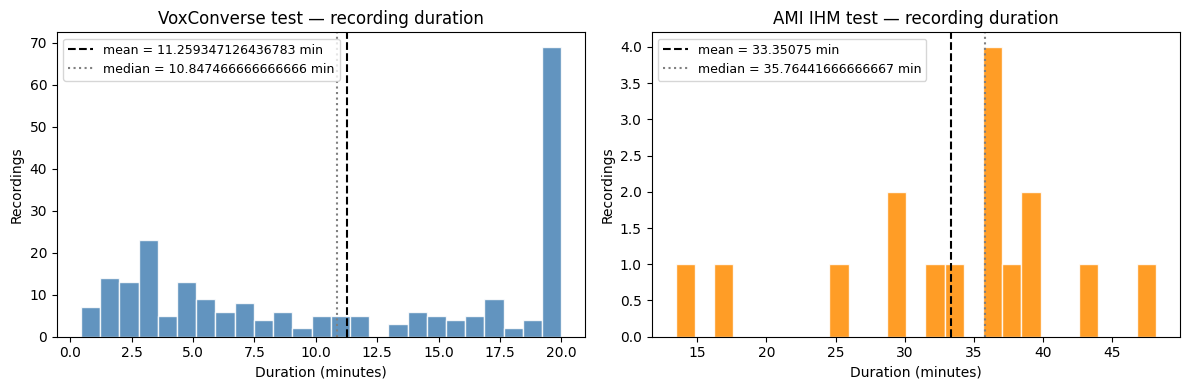

In [40]:
available = [(m_vc, "VoxConverse test", "steelblue")]

available.append((m_ami, "AMI IHM test", "darkorange"))

fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 4))
if len(available) == 1:
    axes = [axes]

for ax, (df, name, color) in zip(axes, available):
    d = df["duration_sec"] / 60
    ax.hist(d, bins=25, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(d.mean(),   color="black", linestyle="--", label=f"mean = {d.mean()} min")
    ax.axvline(d.median(), color="grey",  linestyle=":", label=f"median = {d.median()} min")
    ax.set_title(f"{name} — recording duration")
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("Recordings")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / "01_duration.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. EDA — Speaker Count

Speaker count per recording directly affects diarization difficulty: <br>
1) More speakers means harder clustering <br>
2) Recordings with 1 speaker are trivial

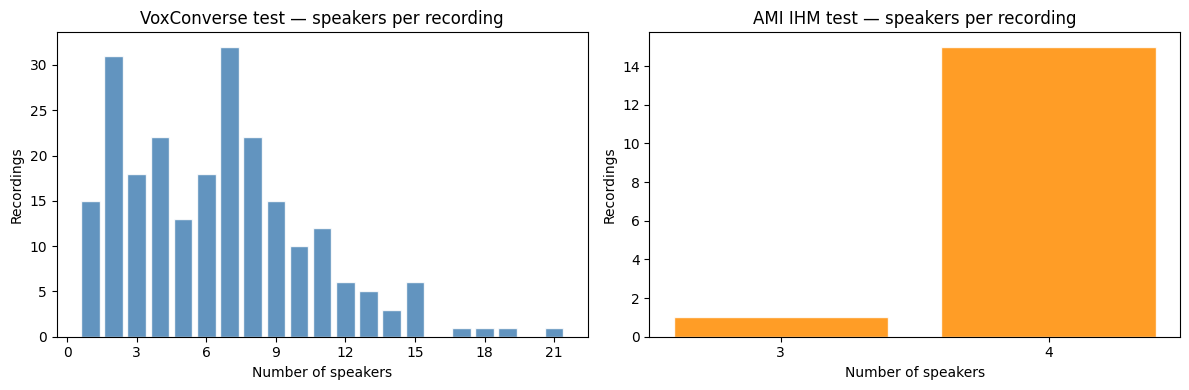

In [41]:
fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 4))
if len(available) == 1:
    axes = [axes]

for ax, (df, name, color) in zip(axes, available):
    counts = df["n_speakers"].dropna().astype(int).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"{name} — speakers per recording")
    ax.set_xlabel("Number of speakers")
    ax.set_ylabel("Recordings")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    single = (df["n_speakers"] == 1).sum()

plt.tight_layout()
plt.savefig(EDA_DIR / "02_speaker_count.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. EDA — Overlap Ratio

Overlap ratio = fraction of recording time where 2+ speakers are active simultaneously.

VoxConverse test: overlap mean = 3.2696120689655173%,  max = 38.48%
recordings with > 20% overlap = 6
AMI IHM test: overlap mean = 11.58%,  max = 26.229999999999997%
recordings with > 20% overlap = 4


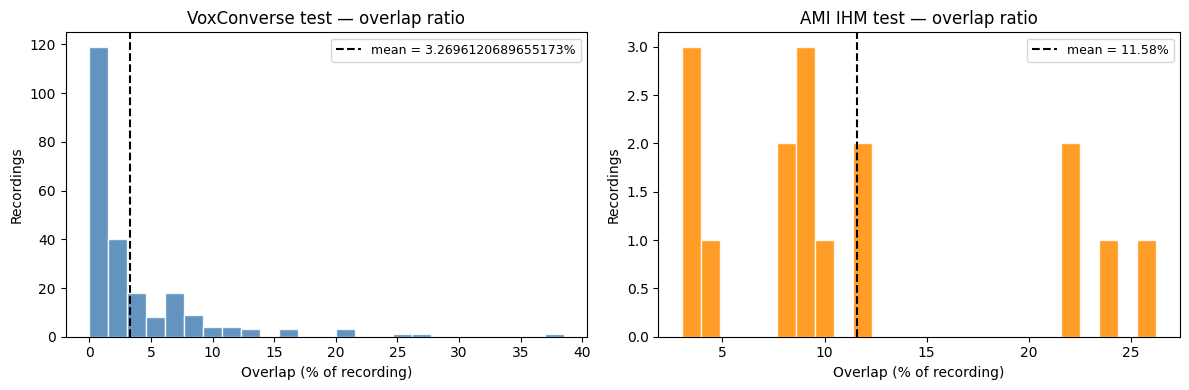

In [42]:
fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 4))
if len(available) == 1:
    axes = [axes]

for ax, (df, name, color) in zip(axes, available):
    ov = df["overlap_ratio"].dropna() * 100
    ax.hist(ov, bins=25, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(ov.mean(), color="black", linestyle="--", label=f"mean = {ov.mean()}%")
    ax.set_title(f"{name} — overlap ratio")
    ax.set_xlabel("Overlap (% of recording)")
    ax.set_ylabel("Recordings")
    ax.legend(fontsize=9)
    print(f"{name}: overlap mean = {ov.mean()}%,  max = {ov.max()}%")
    print(f"recordings with > 20% overlap = {(ov > 20).sum()}")

plt.tight_layout()
plt.savefig(EDA_DIR / "03_overlap_ratio.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. EDA — Segment Duration


In [47]:
def collect_all_segments_vc(dataset):
    parts = []
    for i, sample in enumerate(tqdm(dataset, desc="Collecting segments")):
        file_id = sample.get("audio_id", sample.get("id", f"vc_{i:05d}"))
        df = parse_voxconverse_sample(sample, file_id)
        if not df.empty:
            parts.append(df)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

def collect_all_segments_ami(rttm_dir: Path) -> pd.DataFrame:
    parts = []
    for rttm_path in sorted(rttm_dir.glob("*.rttm")):
        df = parse_rttm_file(rttm_path)
        if not df.empty:
            parts.append(df)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


In [54]:
segs_vc = collect_all_segments_vc(vc_raw)

short = (segs_vc["duration"] < 0.5).sum()
total = len(segs_vc)
print(f"VoxConverse total segments : {total:,}")
print(f"mean duration: {segs_vc['duration'].mean():.2f} s")
print(f"median: {segs_vc['duration'].median():.2f} s")
print(f"< 0.5 s: {short:,}  ({100*short/total:.1f}%)")

VoxConverse total segments : 19,479
mean duration: 7.43 s
median: 2.84 s
< 0.5 s: 1,345  (6.9%)


In [52]:
segs_ami = collect_all_segments_ami(RTTM_DIR)

short = (segs_ami["duration"] < 0.5).sum()
total = len(segs_ami)
print(f"AMI total segments: {total:,}")
print(f"mean duration: {segs_ami['duration'].mean():.2f} s")
print(f"median: {segs_ami['duration'].median():.2f} s")
print(f"< 0.5 s: {short:,}  ({100*short/total:.1f}%)")

AMI total segments: 7,493
mean duration: 4.10 s
median: 1.38 s
< 0.5 s: 2,179  (29.1%)


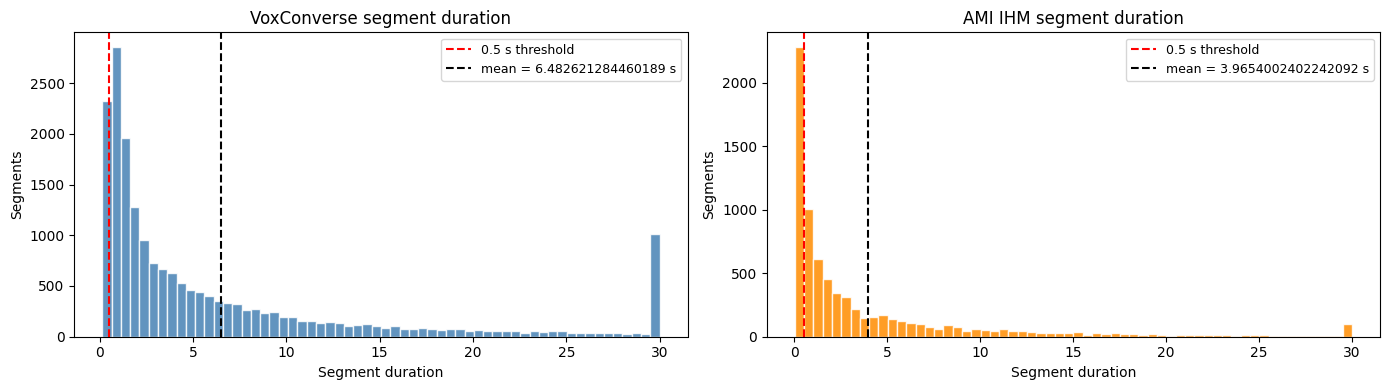

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
z_axes = zip(axes, [
    (segs_vc, "VoxConverse", "steelblue"),
    (segs_ami, "AMI IHM", "darkorange"),
])
for ax, (segs, name, color) in z_axes:
    if segs.empty:
        ax.set_visible(False)
        continue
    d = segs["duration"].clip(upper=30)
    ax.hist(d, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0.5, color="red", linestyle="--", label="0.5 s threshold")
    ax.axvline(d.mean(), color="black", linestyle="--", label=f"mean = {d.mean()} s")
    ax.set_title(f"{name} segment duration")
    ax.set_xlabel("Segment duration")
    ax.set_ylabel("Segments")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / "04_segment_duration.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Dataset Summary Table

In [51]:
def diar_summary(df, name):
    return {
        "Dataset": name,
        "# Recordings": len(df),
        "Total hours": round(df["duration_sec"].sum() / 3600, 2),
        "Duration mean (min)": round(df["duration_sec"].mean() / 60, 1),
        "Duration min (min)": round(df["duration_sec"].min() / 60, 1),
        "Duration max (min)": round(df["duration_sec"].max() / 60, 1),
        "Speakers mean": round(df["n_speakers"].mean(), 1),
        "Speakers range": f"{int(df['n_speakers'].min())}–{int(df['n_speakers'].max())}",
        "Overlap mean": f"{100*df['overlap_ratio'].mean()}%",
    }

rows = [diar_summary(m_vc, "VoxConverse test")]
rows.append(diar_summary(m_ami, "AMI IHM test"))

summary = pd.DataFrame(rows).set_index("Dataset")
print(summary.T.to_string())
summary.to_csv(MANIFEST_DIR / "diar_dataset_summary.csv")

Dataset                 VoxConverse test AMI IHM test
# Recordings                         232           16
Total hours                        43.54         8.89
Duration mean (min)                 11.3         33.4
Duration min (min)                   0.4         13.4
Duration max (min)                  20.0         48.2
Speakers mean                        6.5          3.9
Speakers range                      1–21          3–4
Overlap mean         3.2696120689655177%       11.58%
